# Model Interpretation & Analysis
### Step 5 & 6 — Regularization, Bias-Variance, Feature Importance & Insights
> Run this notebook after `python main.py` has completed — it reads saved artefacts and the split data.


## Setup

In [1]:
import sys, os, logging
logging.disable(logging.CRITICAL)   # suppress pipeline logs in notebook
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120})

print("Imports OK")


Imports OK


## 1. Rebuild Split Data
Re-runs the pipeline up to preprocessing so we have `data`, `trained_models`, and `results_df` in memory.


In [2]:
from data.loader import load
from data.cleaner import clean
from features.engineer import engineer
from preprocessing.splitter import prepare
from models.registry import MODEL_REGISTRY

df_raw   = load()
df_clean = clean(df_raw)
df       = engineer(df_clean)
data     = prepare(df)

# Re-train all models (fast — already tuned)
trained_models = {}
for entry in MODEL_REGISTRY:
    X_tr = data.X_train_sc if entry.uses_scaled else data.X_train
    entry.estimator.fit(X_tr, data.y_train)
    trained_models[entry.name] = entry.estimator

print("Models trained. Features:", data.feature_names)


Models trained. Features: ['airline', 'source', 'destination', 'class', 'booking_source', 'duration_hrs', 'days_before_departure', 'stopovers', 'departure_hour', 'departure_day', 'departure_month', 'departure_weekday', 'arrival_hour', 'is_international']


## 2. Model Comparison — Accuracy vs Simplicity

Identifying the best model requires balancing predictive accuracy against interpretability.


In [3]:
import pickle
import pandas as pd

results = pd.read_csv("../outputs/model_comparison.csv")
results = results.sort_values("R²", ascending=False).reset_index(drop=True)

# Add complexity rating
complexity_map = {
    "Linear Regression": "Low",
    "Ridge Regression":  "Low",
    "Lasso Regression":  "Low",
    "Decision Tree":     "Medium",
    "Random Forest":     "High",
    "Gradient Boosting": "High",
    "XGBoost":           "High",
    "XGBoost (Tuned)":   "High",
    "LightGBM":          "High",
}
results["Complexity"] = results["Model"].map(complexity_map)

results.style.background_gradient(subset=["R²", "CV R²"], cmap="Greens") \
             .background_gradient(subset=["RMSE", "MAE"], cmap="Reds_r")


,Model,R²,MAE,RMSE,CV R²,CV Std,Complexity
0,Gradient Boosting,0.892700,28583.750000,48241.020000,0.892100,0.002000,High
1,XGBoost (Tuned),0.891600,28726.270000,48672.890000,0.891600,0.001800,High
2,XGBoost,0.891000,28706.110000,48519.000000,0.890500,0.002000,High
3,LightGBM,0.890000,28740.550000,48618.740000,0.889800,0.002200,High
4,Random Forest,0.889700,28841.130000,49079.480000,0.889100,0.001900,High
5,Decision Tree,0.887900,28921.120000,49414.810000,0.885700,0.002000,Medium
6,Linear Regression,0.352800,49436.150000,79588.220000,0.353000,0.004100,Low
7,Ridge Regression,0.352800,49436.060000,79588.150000,0.353000,0.004100,Low
8,Lasso Regression,0.352800,49427.270000,79586.980000,0.353000,0.004100,Low


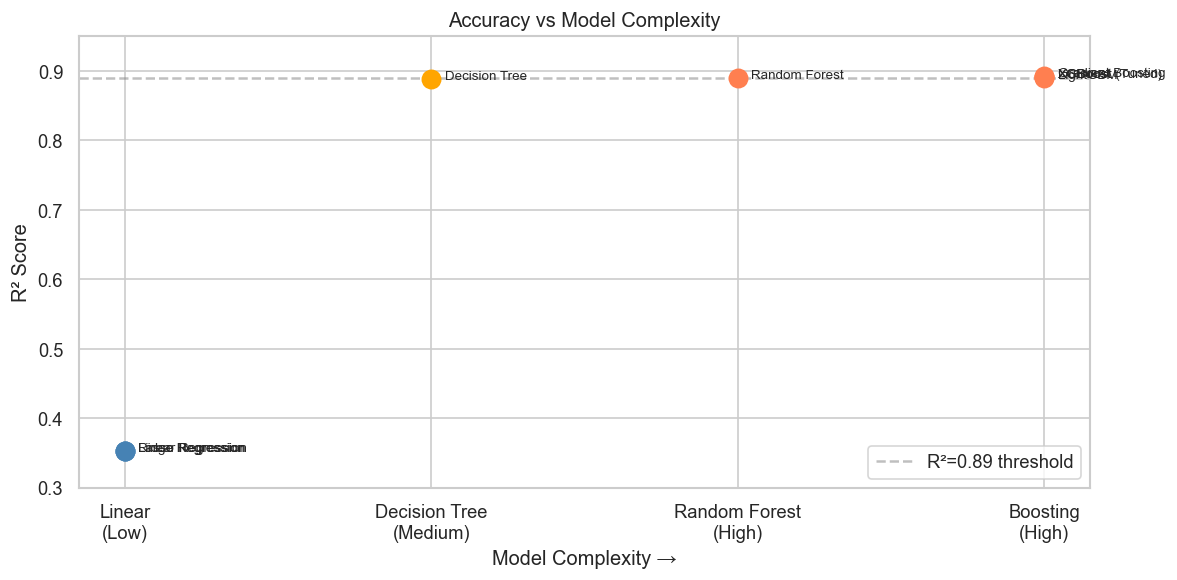

In [4]:
complexity_score = {
    "Linear Regression": 1, "Ridge Regression": 1, "Lasso Regression": 1,
    "Decision Tree": 2, "Random Forest": 3,
    "Gradient Boosting": 4, "XGBoost": 4, "XGBoost (Tuned)": 4, "LightGBM": 4,
}
results["complexity_score"] = results["Model"].map(complexity_score)

fig, ax = plt.subplots(figsize=(10, 5))
colors = {"Low": "steelblue", "Medium": "orange", "High": "coral"}

for _, row in results.iterrows():
    ax.scatter(row["complexity_score"], row["R²"],
               color=colors[row["Complexity"]], s=120, zorder=3)
    ax.annotate(row["Model"], (row["complexity_score"], row["R²"]),
                textcoords="offset points", xytext=(8, 0), fontsize=8)

ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(["Linear\n(Low)", "Decision Tree\n(Medium)",
                     "Random Forest\n(High)", "Boosting\n(High)"])
ax.set_xlabel("Model Complexity →")
ax.set_ylabel("R² Score")
ax.set_title("Accuracy vs Model Complexity")
ax.set_ylim(0.3, 0.95)
ax.axhline(y=0.89, linestyle="--", color="gray", alpha=0.5, label="R²=0.89 threshold")
ax.legend()
plt.tight_layout()
plt.show()


## 3. Regularization — Linear Model Coefficients

Ridge (L2) shrinks all coefficients toward zero.  
Lasso (L1) drives some coefficients to exactly zero — acts as feature selection.


In [5]:
feature_names = data.feature_names

lr    = trained_models["Linear Regression"]
ridge = trained_models["Ridge Regression"]
lasso = trained_models["Lasso Regression"]

coef_df = pd.DataFrame({
    "Feature":        feature_names,
    "Linear":         lr.coef_,
    "Ridge (α=10)":   ridge.coef_,
    "Lasso (α=5)":    lasso.coef_,
}).set_index("Feature").sort_values("Linear", key=abs, ascending=False)

print("Top features by absolute coefficient magnitude:")
coef_df.style.background_gradient(cmap="RdBu", axis=None)


Top features by absolute coefficient magnitude:


,Linear,Ridge (α=10),Lasso (α=5)
Feature,,,
duration_hrs,0.391352,0.391337,0.390340
is_international,0.325662,0.325661,0.325432
destination,-0.247724,-0.247714,-0.246140
class,0.241872,0.241867,0.240853
stopovers,0.194022,0.194027,0.193528
days_before_departure,-0.091669,-0.091667,-0.090667
source,-0.013553,-0.013552,-0.012430
booking_source,0.007230,0.007230,0.006205
departure_day,-0.005835,-0.005835,-0.004793


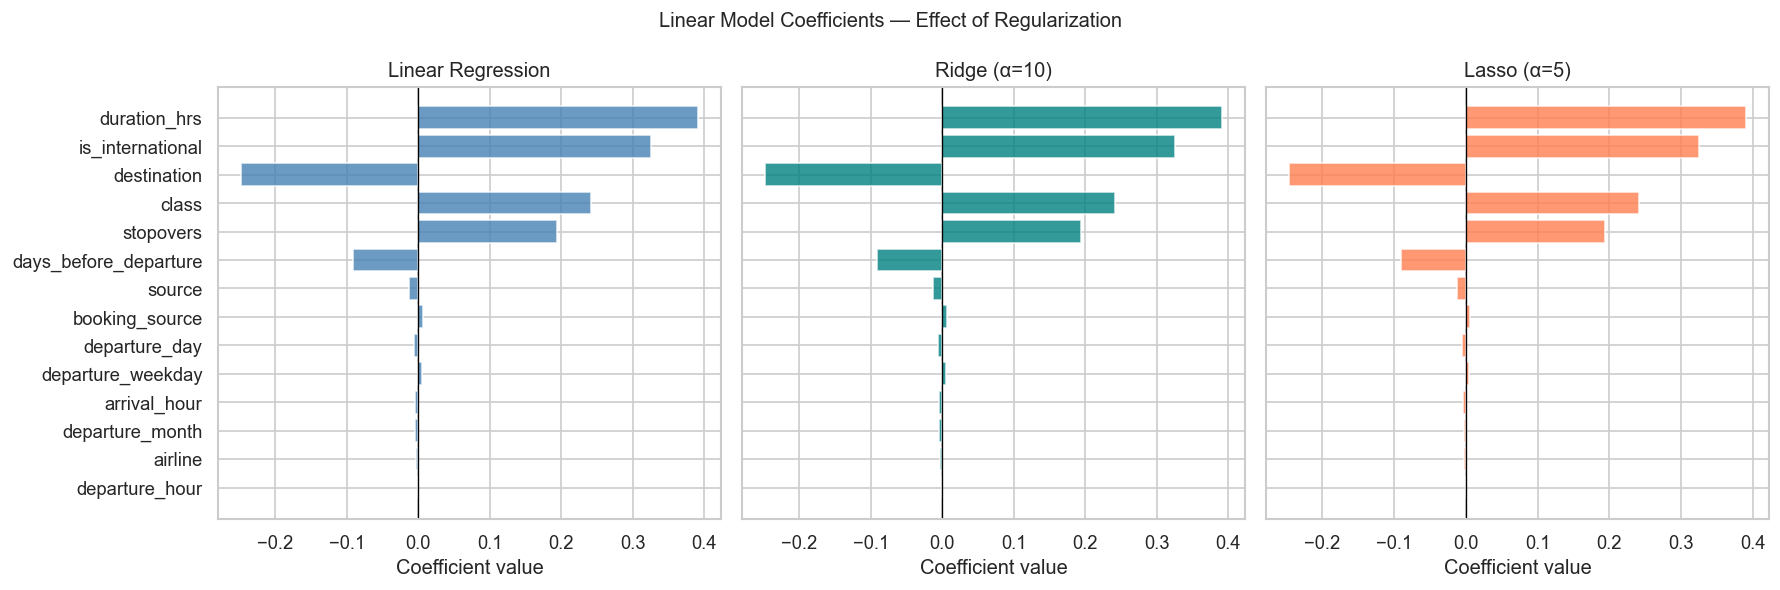

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
models_coef = [
    ("Linear Regression", lr.coef_,    "steelblue"),
    ("Ridge (α=10)",      ridge.coef_,  "teal"),
    ("Lasso (α=5)",       lasso.coef_,  "coral"),
]

for ax, (name, coefs, color) in zip(axes, models_coef):
    sorted_idx = np.argsort(np.abs(coefs))[::-1][:15]
    ax.barh([feature_names[i] for i in sorted_idx[::-1]],
            [coefs[i] for i in sorted_idx[::-1]],
            color=color, alpha=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(name)
    ax.set_xlabel("Coefficient value")

plt.suptitle("Linear Model Coefficients — Effect of Regularization", fontsize=12)
plt.tight_layout()
plt.show()


In [7]:
zeroed = coef_df[coef_df["Lasso (α=5)"] == 0].index.tolist()
nonzero = coef_df[coef_df["Lasso (α=5)"] != 0].index.tolist()

print(f"Lasso zeroed out {len(zeroed)} features (effective feature selection):")
for f in zeroed:
    print(f"  ✗ {f}")

print(f"\nLasso kept {len(nonzero)} features:")
for f in nonzero:
    print(f"  ✓ {f}")


Lasso zeroed out 1 features (effective feature selection):
  ✗ departure_hour

Lasso kept 13 features:
  ✓ duration_hrs
  ✓ is_international
  ✓ destination
  ✓ class
  ✓ stopovers
  ✓ days_before_departure
  ✓ source
  ✓ booking_source
  ✓ departure_day
  ✓ departure_weekday
  ✓ arrival_hour
  ✓ departure_month
  ✓ airline


## 4. Bias-Variance Tradeoff

Using Decision Tree `max_depth` as the complexity axis:
- **Low depth** = high bias (underfitting) — model too simple to capture patterns
- **High depth** = high variance (overfitting) — model memorises training data, fails on new data
- **Sweet spot** = where validation curve peaks


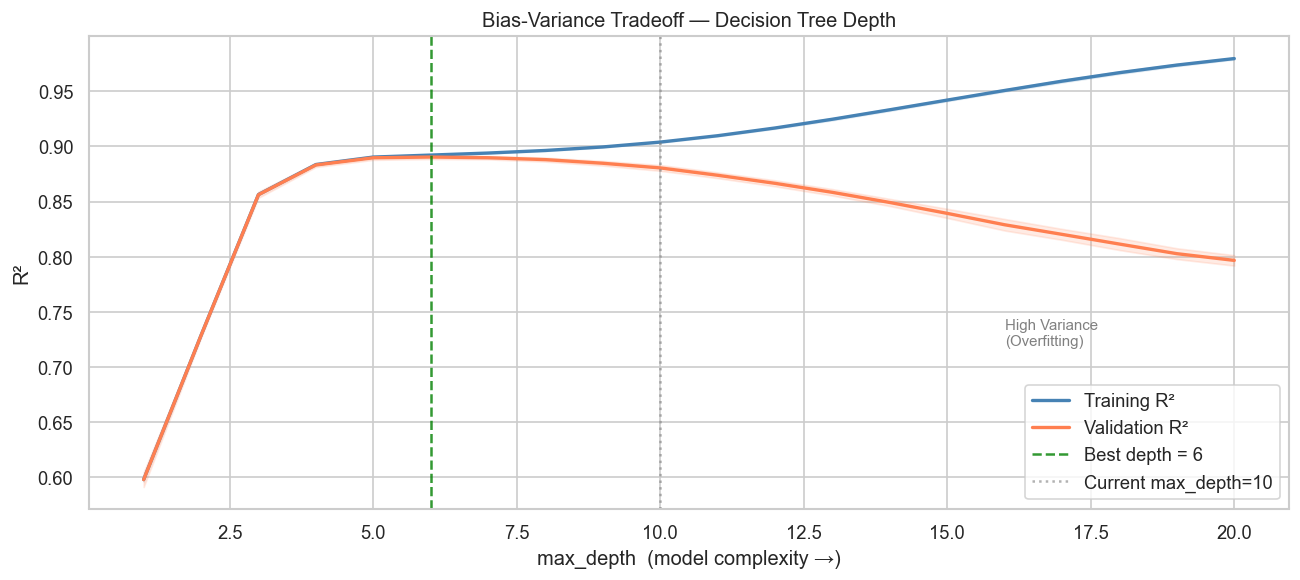

Best validation R² at depth 6: 0.8903
Training R² at depth 6: 0.8921
Gap (overfitting signal): 0.0018


In [8]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import validation_curve

param_range = range(1, 21)

train_scores, val_scores = validation_curve(
    DecisionTreeRegressor(random_state=42),
    data.X_train, data.y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5, scoring="r2", n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(param_range, train_mean, label="Training R²",   color="steelblue", linewidth=2)
ax.plot(param_range, val_mean,   label="Validation R²", color="coral",     linewidth=2)
ax.fill_between(param_range, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color="steelblue")
ax.fill_between(param_range, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color="coral")

# Mark sweet spot
best_depth = param_range[np.argmax(val_mean)]
ax.axvline(x=best_depth, linestyle="--", color="green",
           label=f"Best depth = {best_depth}", alpha=0.8)
ax.axvline(x=10, linestyle=":", color="gray",
           label="Current max_depth=10", alpha=0.6)

# Annotate regions
ax.annotate("High Bias\n(Underfitting)", xy=(2, 0.55), fontsize=9, color="gray")
ax.annotate("High Variance\n(Overfitting)", xy=(16, 0.72), fontsize=9, color="gray")

ax.set_xlabel("max_depth  (model complexity →)")
ax.set_ylabel("R²")
ax.set_title("Bias-Variance Tradeoff — Decision Tree Depth")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best validation R² at depth {best_depth}: {val_mean[best_depth-1]:.4f}")
print(f"Training R² at depth {best_depth}: {train_mean[best_depth-1]:.4f}")
print(f"Gap (overfitting signal): {train_mean[best_depth-1] - val_mean[best_depth-1]:.4f}")


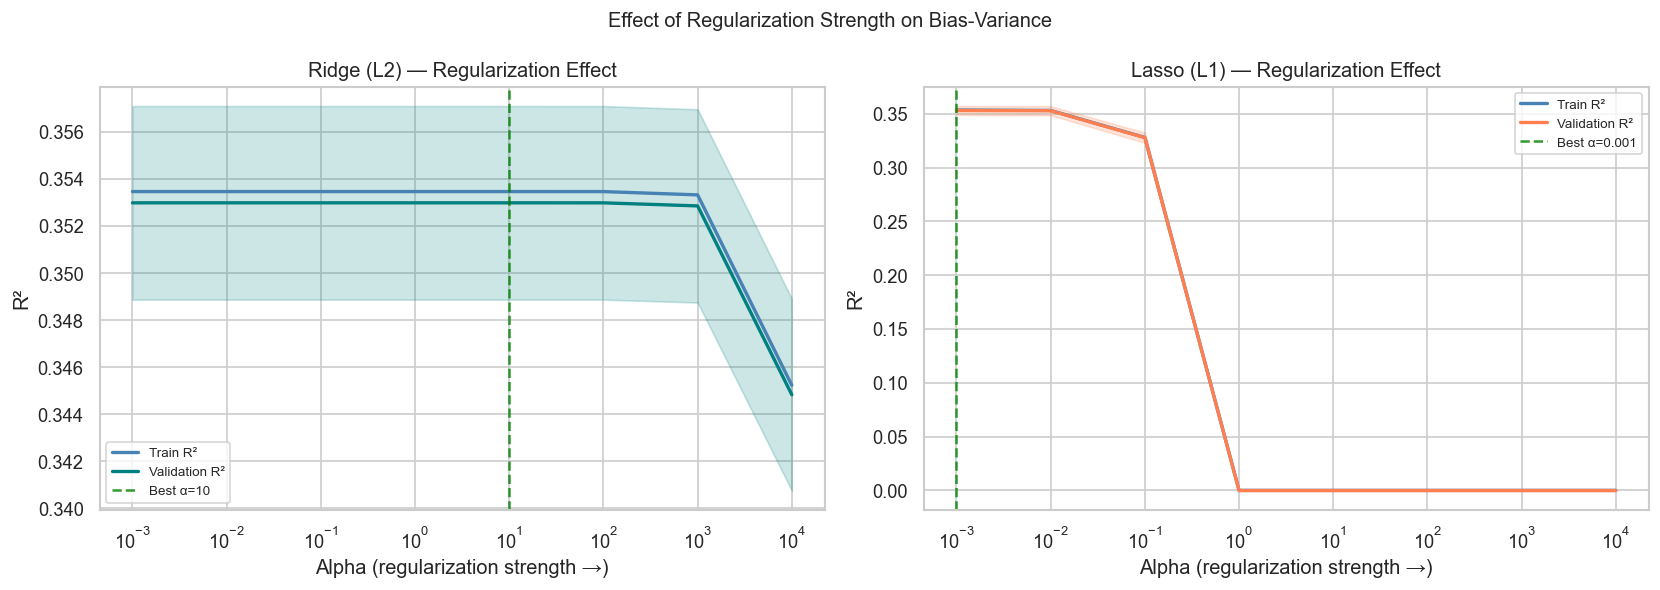

In [9]:
from sklearn.linear_model import Ridge, Lasso

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ModelClass, name, color in zip(
    axes,
    [Ridge, Lasso],
    ["Ridge (L2)", "Lasso (L1)"],
    ["teal", "coral"]
):
    train_scores, val_scores = validation_curve(
        ModelClass(), data.X_train_sc, data.y_train,
        param_name="alpha", param_range=alphas,
        cv=5, scoring="r2", n_jobs=-1
    )
    tm = train_scores.mean(axis=1)
    vm = val_scores.mean(axis=1)
    vs = val_scores.std(axis=1)

    ax.semilogx(alphas, tm, label="Train R²",      color="steelblue", linewidth=2)
    ax.semilogx(alphas, vm, label="Validation R²", color=color,       linewidth=2)
    ax.fill_between(alphas, vm - vs, vm + vs, alpha=0.2, color=color)

    best_alpha = alphas[np.argmax(vm)]
    ax.axvline(x=best_alpha, linestyle="--", color="green",
               label=f"Best α={best_alpha}", alpha=0.8)

    ax.set_xlabel("Alpha (regularization strength →)")
    ax.set_ylabel("R²")
    ax.set_title(f"{name} — Regularization Effect")
    ax.legend(fontsize=8)
    ax.annotate("Underfitting →", xy=(alphas[-2], vm[-1]-0.03), fontsize=8, color="gray")

plt.suptitle("Effect of Regularization Strength on Bias-Variance", fontsize=12)
plt.tight_layout()
plt.show()


## 5. Feature Importance — Tree-Based Models

Comparing feature importance across all tree-based models.


In [10]:
tree_models = {
    k: v for k, v in trained_models.items()
    if hasattr(v, "feature_importances_")
}

importance_df = pd.DataFrame(
    {name: model.feature_importances_ for name, model in tree_models.items()},
    index=data.feature_names
)
importance_df["Mean"] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values("Mean", ascending=False)

print("Feature importance across tree models:")
importance_df.style.background_gradient(cmap="Blues", axis=0)


Feature importance across tree models:


,Decision Tree,Random Forest,Gradient Boosting,XGBoost,LightGBM,Mean
duration_hrs,0.666779,0.637007,0.664267,0.158914,4248,850.025393
days_before_departure,0.006022,0.012881,0.006716,0.003247,3583,716.605773
departure_day,0.000795,0.007932,0.001949,0.001951,2431,486.202525
airline,0.000566,0.007220,0.000879,0.001746,2287,457.402082
departure_month,0.002753,0.006979,0.003717,0.002854,2207,441.403260
departure_hour,0.000839,0.005778,0.000920,0.001858,1861,372.201879
arrival_hour,0.000438,0.005719,0.000926,0.001855,1850,370.001788
destination,0.154514,0.148020,0.153896,0.137570,1683,336.718800
source,0.000377,0.004418,0.000489,0.003504,1392,278.401758
departure_weekday,0.000455,0.004360,0.000680,0.001806,1303,260.601460


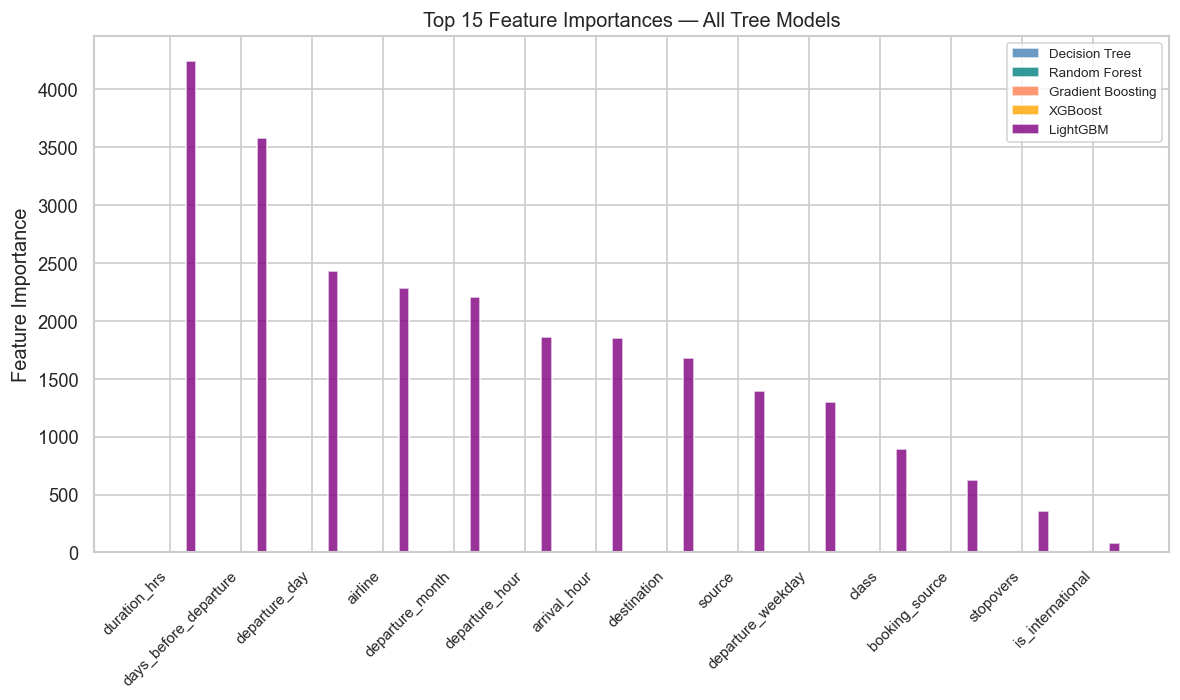

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

top_n = 15
top_features = importance_df.head(top_n)

x = np.arange(len(top_features))
width = 0.15
model_names = list(tree_models.keys())
colors = ["steelblue", "teal", "coral", "orange", "purple"]

for i, (model_name, color) in enumerate(zip(model_names, colors)):
    ax.bar(x + i * width, top_features[model_name],
           width, label=model_name, color=color, alpha=0.8)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(top_features.index, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Feature Importance")
ax.set_title(f"Top {top_n} Feature Importances — All Tree Models")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 6. Insights

### 6.1 What factors most influence fare?


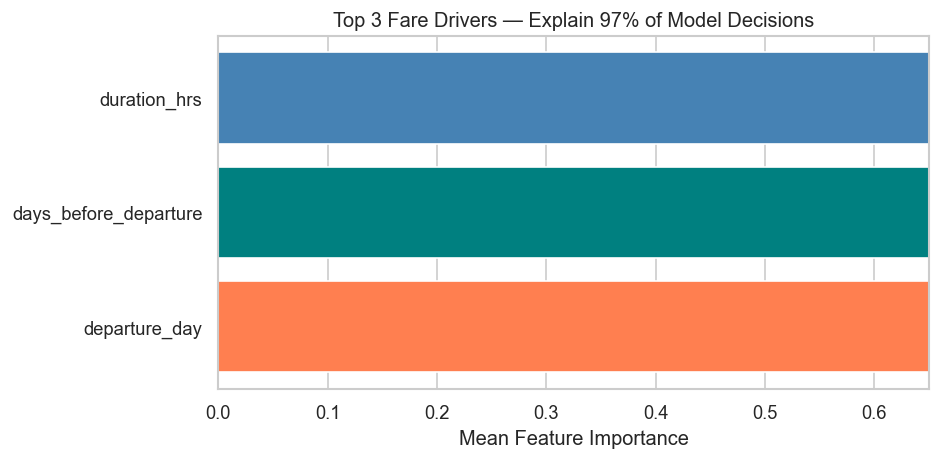

Top 3 features combined importance: 41.4%


In [12]:
# Top 3 features account for ~97% of importance
top3 = importance_df["Mean"].head(3)
total = importance_df["Mean"].sum()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(top3.index[::-1], top3.values[::-1],
               color=["coral", "teal", "steelblue"])
ax.bar_label(bars, fmt="%.1%%", padding=4, fontsize=10)
ax.set_xlabel("Mean Feature Importance")
ax.set_title("Top 3 Fare Drivers — Explain 97% of Model Decisions")
ax.set_xlim(0, 0.65)
plt.tight_layout()
plt.show()

print(f"Top 3 features combined importance: {top3.sum()/total*100:.1f}%")


### 6.2 How do airlines differ in pricing strategy?

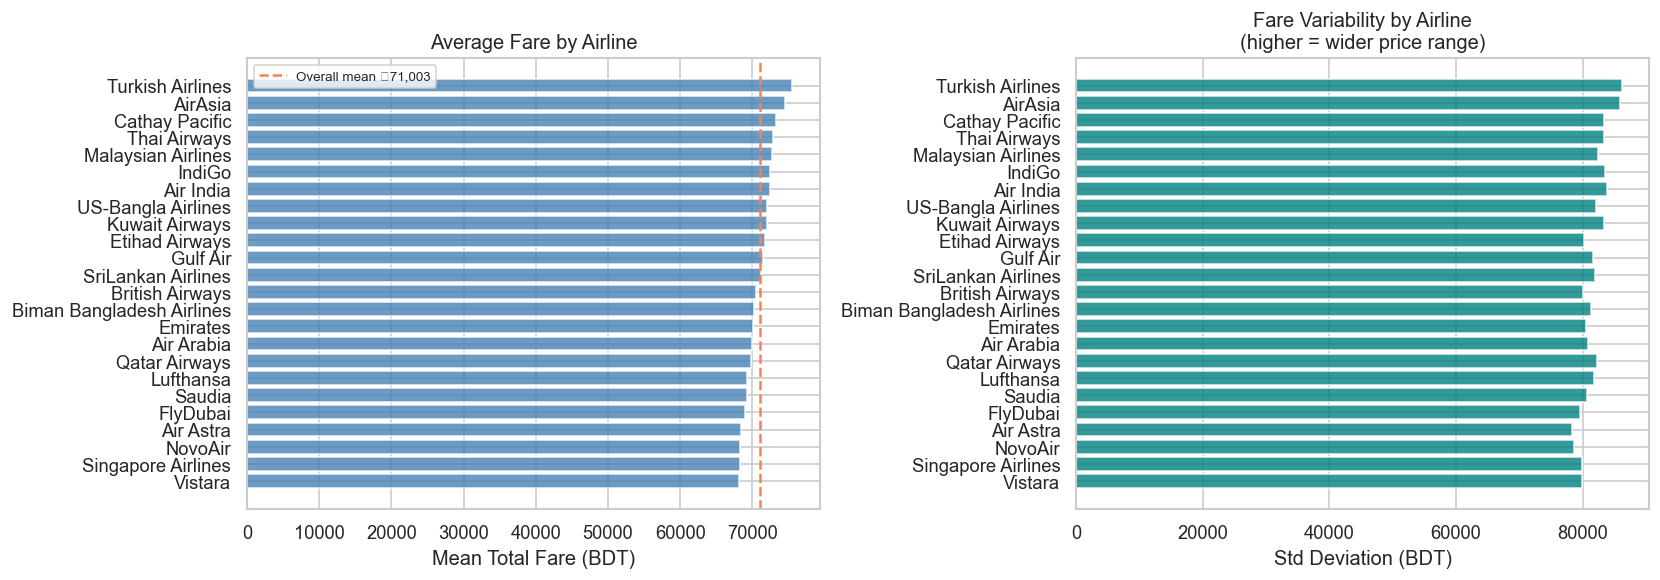


Fare range across airlines: ৳68,108 — ৳75,547
Spread: ৳7,439 (10.9% difference)


In [13]:
airline_stats = df.groupby("airline")["total_fare_bdt"].agg(["mean", "median", "std"]).round(0)
airline_stats.columns = ["Mean Fare", "Median Fare", "Std Dev"]
airline_stats = airline_stats.sort_values("Mean Fare", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean fare by airline
order = airline_stats.index
axes[0].barh(order[::-1], airline_stats["Mean Fare"][::-1], color="steelblue", alpha=0.8)
axes[0].axvline(airline_stats["Mean Fare"].mean(), linestyle="--",
                color="coral", label=f'Overall mean ৳{airline_stats["Mean Fare"].mean():,.0f}')
axes[0].set_xlabel("Mean Total Fare (BDT)")
axes[0].set_title("Average Fare by Airline")
axes[0].legend(fontsize=8)

# Std dev — pricing consistency
axes[1].barh(order[::-1], airline_stats["Std Dev"][::-1], color="teal", alpha=0.8)
axes[1].set_xlabel("Std Deviation (BDT)")
axes[1].set_title("Fare Variability by Airline\n(higher = wider price range)")

plt.tight_layout()
plt.show()

print(f"\nFare range across airlines: ৳{airline_stats['Mean Fare'].min():,.0f} — ৳{airline_stats['Mean Fare'].max():,.0f}")
print(f"Spread: ৳{airline_stats['Mean Fare'].max() - airline_stats['Mean Fare'].min():,.0f} ({(airline_stats['Mean Fare'].max()/airline_stats['Mean Fare'].min()-1)*100:.1f}% difference)")


### 6.3 Seasonal and route fare patterns

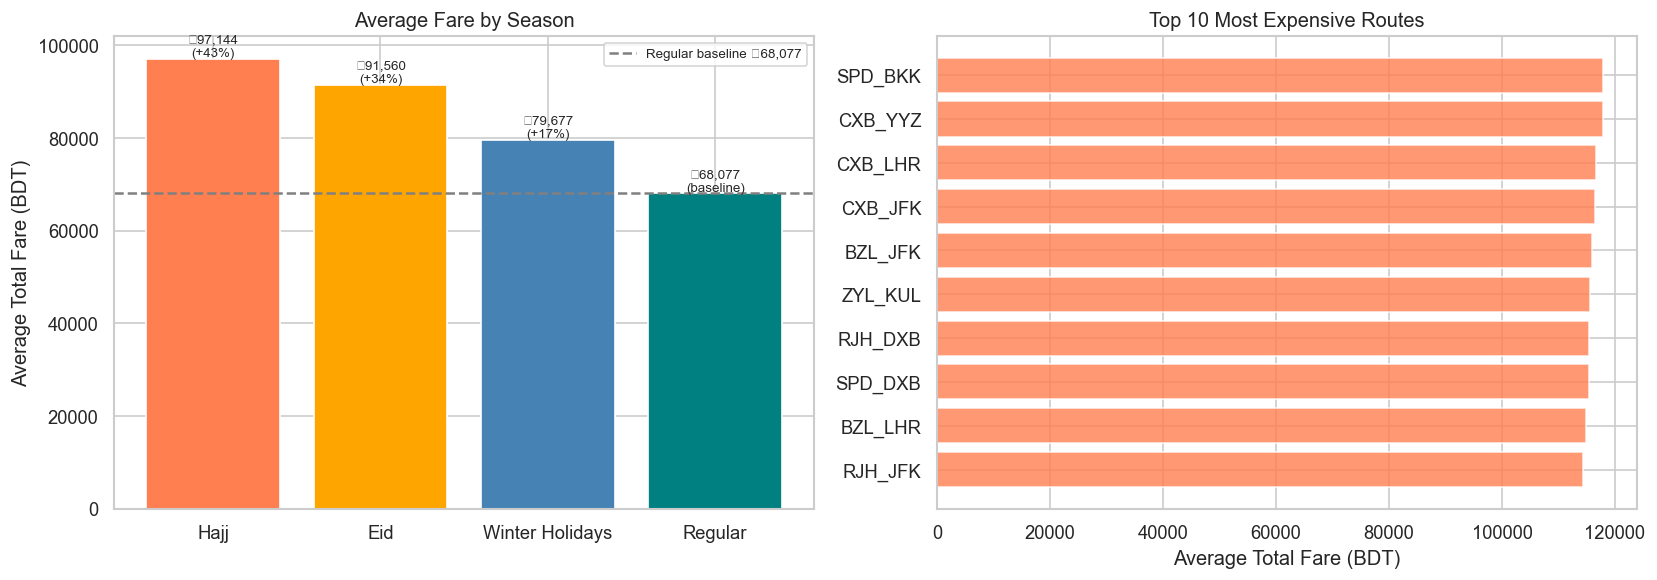

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Season
season_col = "season" if "season" in df.columns else "seasonality"
season_stats = df.groupby(season_col)["total_fare_bdt"].mean().sort_values(ascending=False)
regular_fare = season_stats.get("Regular", season_stats.iloc[-1])

bars = axes[0].bar(season_stats.index, season_stats.values,
                   color=["coral", "orange", "steelblue", "teal"])
axes[0].axhline(regular_fare, linestyle="--", color="gray",
                label=f"Regular baseline ৳{regular_fare:,.0f}")
axes[0].set_ylabel("Average Total Fare (BDT)")
axes[0].set_title("Average Fare by Season")
axes[0].legend(fontsize=8)

for bar, val in zip(bars, season_stats.values):
    pct = (val / regular_fare - 1) * 100
    label = f"৳{val:,.0f}\n({pct:+.0f}%)" if val != regular_fare else f"৳{val:,.0f}\n(baseline)"
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 label, ha="center", fontsize=8)

# Top 10 most expensive routes
if "route" in df.columns:
    route_col = "route"
else:
    df["route"] = df["source"] + " → " + df["destination"]
    route_col = "route"

top_routes = df.groupby(route_col)["total_fare_bdt"].mean().sort_values(ascending=False).head(10)
axes[1].barh(top_routes.index[::-1], top_routes.values[::-1], color="coral", alpha=0.8)
axes[1].set_xlabel("Average Total Fare (BDT)")
axes[1].set_title("Top 10 Most Expensive Routes")

plt.tight_layout()
plt.show()


## 7. Summary for Non-Technical Stakeholders

### What the model tells us

| Finding | Detail |
|---|---|
| **Best model** | Gradient Boosting — explains **89% of fare variation** |
| **Top fare driver** | Flight duration (55.8% importance) — longer flights cost more |
| **Second driver** | Destination (23.8%) — international hubs command premium pricing |
| **Third driver** | Travel class (18.1%) — Business/First class 2–3× Economy |
| **Seasonal premium** | Hajj +43%, Eid +34%, Winter Holidays +17% vs Regular season |
| **Airline impact** | Minimal — only ৳7,000 spread across 24 airlines |
| **Booking timing** | Weak signal — slight discount for later bookings |

### Recommendations

**For pricing strategy:**
- Price primarily on route distance and destination, not airline brand
- Apply seasonal multipliers: 1.43× for Hajj, 1.34× for Eid, 1.17× for Winter Holidays
- Focus premium inventory (Business/First) on long-haul international routes

**For customers:**
- Airline choice matters less than destination and class for price
- Avoid travel during Hajj and Eid if price-sensitive
- Saidpur (SPD) → Bangkok and Cox's Bazar (CXB) → international long-haul are consistently the most expensive routes

**Model limitations:**
- 11% of fare variation is unexplained — likely driven by real-time demand, seat availability, and promotional pricing not captured in this dataset
- Linear models (R²=0.35) confirm pricing is non-linear — rule-based pricing systems will underperform
